# **Kaggle Challenge 3: Đề tài dự đoán thể loại nhạc.**
# **PHẦN 1: TÌM HIỂU CƠ SỞ VÀ DỌN DẸP DỮ LIỆU**

+ **Mô tả**:
   - Dự báo thể loại nhạc dựa trên 16 đặc trưng.
   - Dữ liệu bao gồm 3 file:
      * train (1).csv: Dataset cho việc huấn luyện.
      * test (2).csv: Dataset cho việc test.
      * sample_submission (2).csv: Mẫu submission.

+ **Mục tiêu**:
   - Xem thông tin chung, kiểm tra tính toàn vẹn và xử lý các giá trị thiếu cho dữ liệu.

+ **Dữ liệu đầu vào**:
	- artist: Tên nghệ sĩ.
	- song: Tên bản nhạc.
	- popularity: Độ phổ biến của bản nhạc.
	- danceability: Độ phù hợp của bản nhạc cho việc nhảy.
	- energy: Mức độ năng động của bản nhạc.
	- key: Giá trị số nguyên ánh xạ theo ký hiệu Lớp Cao Độ (Pitch Class notation), ví dụ 0 = C, 1 = C♯/D♭, 2 = D,...
	- loudness: Cường độ âm thanh của bản nhạc (tính theo decibel)
	- mode: Điệu thức của một bản nhạc (với mode = 1 là thang âm trưởng, mode = 0 là thang âm thứ)
	- speechiness: Tính chất giọng nói. Với giá trị trên 0.66 là gần như hoàn toàn là lời nói, giá trị từ 0.33 đến 0.66 là những bản nhạc chứa cả nhạc và lời nói, giá trị từ dưới 0.33 là gần như hoàn toàn là nhạc.
	- acousticness: Tính chất mộc của bản nhạc, có giá trị từ 0.0 đến 1.0, với 1.0 là nhạc mộc (được tạo ra bởi công cụ truyền thống),
	và 0.0 là nhạc điện tử hoặc sử dụng nhạc cụ khuếch đại/tổng hợp.
	- instrumentalness: Bản nhạc có lời hay không. Các âm thanh "Ooh", "aah" được xử lý như không lời. Rap hay lời nói được xử lý là "có lời". Giá trị gần 1.0 thì bản nhạc càng ít có lời, với giá trị gần 0.0 thì bản nhạc chắc chắn có giọng hát.
	- liveness: Hiện sự trực tiếp (sự hiện diện của khán giả, người nghe) trong bản thu âm. Với giá trị trên 0.8 là khả năng rất cao bản thu âm được biểu diễn trực tiếp.
	- valance: Trạng thái cảm xúc tích cực của bản nhạc. Với 1.0 hiện sự vui vẻ, hân hoan, còn 0.0 hiện sự buồn bã, tức giận.
	- tempo: Tốc độ tổng thể ước tính của bản nhạc, được đo bằng số nhịp trên phút (hay BPM).
	- duration: độ dài bản nhạc (đơn vị mili giây).
	- time_signature: số nhịp, phách trong bản nhạc. 

+ **Dữ liệu đầu ra**:
	- class: Thể loại nhạc.



## 2. Chuẩn bị vấn đề.

### 2.1. Import các thư viện cần thiết.

In [96]:
# Load libraries
from IPython import display
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns


### 2.2. Lấy dữ liệu từ dataset.

In [97]:
train_data = pd.read_csv("../data/shai-music-genre-classification/train (1).csv")
test_data = pd.read_csv("../data/shai-music-genre-classification/test (2).csv")

### 2.3. Kiểm tra dữ liệu dataset.

In [98]:
train_data.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


In [99]:
test_data.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),NaN,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,NaN,0.1140,0.298,103.971,232533.0,4
3,14400,WALK THE MOON,Different Colors,52.0,0.480,0.826,NaN,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,NaN,0.0672,0.805,76.030,118439.0,4


## 3. Xem thông tin cơ bản của dữ liệu

### 3.1. Thống kê, mô tả

##### **1) Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ Thông tin chung về dữ liệu

In [100]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

In [101]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  3600 non-null   int64  
 1   Artist Name         3600 non-null   object 
 2   Track Name          3600 non-null   object 
 3   Popularity          3505 non-null   float64
 4   danceability        3600 non-null   float64
 5   energy              3600 non-null   float64
 6   key                 3195 non-null   float64
 7   loudness            3600 non-null   float64
 8   mode                3600 non-null   int64  
 9   speechiness         3600 non-null   float64
 10  acousticness        3600 non-null   float64
 11  instrumentalness    2764 non-null   float64
 12  liveness            3600 non-null   float64
 13  valence             3600 non-null   float64
 14  tempo               3600 non-null   float64
 15  duration_in min/ms  3600 non-null   float64
 16  time_s

In [102]:
train_data.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14396.000000,14063.000000,14396.000000,14396.000000,12787.000000,14396.000000,14396.000000,14396.000000,14396.000000,10855.000000,14396.000000,14396.000000,14396.000000,1.439600e+04,14396.000000,14396.000000
mean,7198.500000,44.525208,0.543105,0.662422,5.953781,-7.900852,0.640247,0.080181,0.246746,0.178129,0.195782,0.486379,122.695372,2.000942e+05,3.924354,6.695679
std,4155.911573,17.418940,0.165517,0.235967,3.200013,4.057362,0.479944,0.085157,0.310922,0.304266,0.159258,0.239476,29.538490,1.116891e+05,0.359520,3.206170
min,1.000000,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.021500,30.557000,5.016500e-01,1.000000,0.000000
25%,3599.750000,33.000000,0.432000,0.508000,3.000000,-9.538000,0.000000,0.034800,0.004280,0.000088,0.097275,0.299000,99.799000,1.654458e+05,4.000000,5.000000
50%,7198.500000,44.000000,0.545000,0.699000,6.000000,-7.013500,1.000000,0.047100,0.081450,0.003920,0.129000,0.480500,120.060000,2.089410e+05,4.000000,8.000000
75%,10797.250000,56.000000,0.658000,0.861000,9.000000,-5.162000,1.000000,0.083100,0.432250,0.201000,0.256000,0.672000,141.988250,2.522470e+05,4.000000,10.000000
max,14396.000000,100.000000,0.989000,1.000000,11.000000,1.342000,1.000000,0.955000,0.996000,0.996000,0.992000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [ ]:
test_data.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
count,3600.000000,3505.000000,3600.000000,3600.000000,3195.000000,3600.000000,3600.000000,3600.000000,3600.000000,2764.000000,3600.000000,3600.000000,3600.000000,3.600000e+03,3600.000000
mean,16196.500000,44.459629,0.544744,0.664197,5.947105,-7.949879,0.622778,0.077813,0.248425,0.175336,0.197720,0.485527,122.335063,2.033447e+05,3.922778
std,1039.374812,17.461328,0.169257,0.233010,3.184676,4.016468,0.484759,0.076914,0.309510,0.303238,0.159040,0.243082,29.705640,1.131593e+05,0.369936
min,14397.000000,1.000000,0.064600,0.000020,1.000000,-34.797000,0.000000,0.022700,0.000001,0.000001,0.014400,0.018300,48.718000,9.871167e-01,1.000000
25%,15296.750000,33.000000,0.430000,0.512000,3.000000,-9.532500,0.000000,0.034800,0.004488,0.000093,0.098575,0.291000,98.515750,1.688360e+05,4.000000
50%,16196.500000,44.000000,0.549000,0.703000,6.000000,-7.043500,1.000000,0.048750,0.080850,0.003755,0.131000,0.481000,120.091000,2.103355e+05,4.000000
75%,17096.250000,56.000000,0.664000,0.859000,9.000000,-5.282250,1.000000,0.082800,0.441250,0.197250,0.265250,0.674000,141.846750,2.533958e+05,4.000000
max,17996.000000,97.000000,0.970000,0.999000,11.000000,1.355000,1.000000,0.886000,0.996000,0.973000,1.000000,0.984000,214.396000,1.412451e+06,5.000000


**Nhận xét**:
+ Dữ liệu có 14396 dòng cho việc train, 3600 dòng cho việc test.
+ Dữ liệu có 16 tính chất để phân loại.
+ Một số dòng trong TrackName có các ký hiệu lạ (có thể do mã hóa sai).
+ Có 2 tính chất là int64 (ngoại trừ biến mục tiêu Class trong train), 2 tính chất là object, 12 tính chất là float64
+ Các tính chất như danceability, energy, speechiness, acousticness, instrumentalness, liveness, valence có phân bố $[0, 1]$ (hợp lý vì theo mô tả dữ liệu, các tính chất này có phân bố từ 0 đến 1).

##### **2) Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không?
+ Dữ liệu có tồn tại giá trị null không?

In [104]:
print("Số cột null ở train: ", (train_data.isnull().sum() > 0).sum())

Số cột null ở train:  3


In [105]:
print("Số cột null ở test: ", (test_data.isnull().sum() > 0).sum()) # Đếm số cột chứa giá trị null

Số cột null ở test:  3


In [106]:
train_data.isnull().sum().sort_values(ascending=False).head()

instrumentalness    3541
key                 1609
Popularity           333
Id                     0
Artist Name            0
dtype: int64

In [107]:
test_data.isnull().sum().sort_values(ascending=False).head()

instrumentalness    836
key                 405
Popularity           95
Id                    0
Track Name            0
dtype: int64

In [108]:
print("Số dòng trùng lặp trong train: ", train_data.duplicated().sum())

Số dòng trùng lặp trong train:  0


In [109]:
print("Số dòng trùng lặp trong test: ", test_data.duplicated().sum())

Số dòng trùng lặp trong test:  0


**Nhận xét**:
+ Dữ liệu trên tập train và test đều thiếu 3 cột (instrumentalness, key, Popularity).
+ Dữ liệu không bị trùng lặp trên train và test.

**Như vậy, cần xử lý các giá trị bị null trong cả 2 tập train và test.**

#### **3) Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class)**

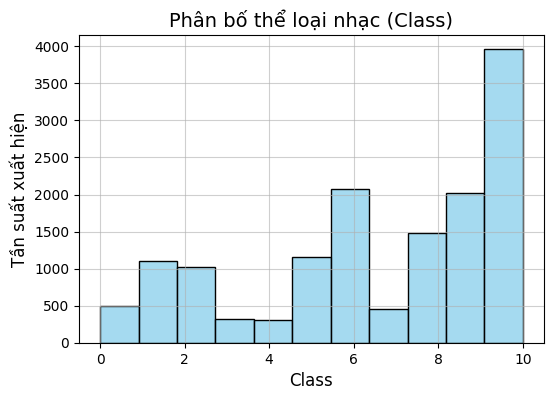

In [126]:
plt.figure(figsize=(6, 4))
sns.histplot(train_data['Class'], bins=train_data['Class'].nunique(), kde=False, color='skyblue')
plt.title("Phân bố thể loại nhạc (Class)", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Tần suất xuất hiện", fontsize=12)
plt.grid(True, alpha=0.6)
plt.savefig("class_dist.jpg")
plt.show()

**Nhận xét:**
- Biến mục tiêu có phân bố từ $[0, 10]$. 
- Biến mục tiêu có sự mất cân bằng (giá trị 3 và 4 phân bố rất ít, trong khi 10 phân bố rất nhiều).

**Như vậy, cần xử lý mất cân bằng dữ liệu trên Class.**

## 4. Dọn dẹp dữ liệu

### 4.1. Xử lý các cột thiếu giá trị.

#### **1) Xử lý trên cột Popularity**
Cột Popularity thiếu 333 phần tử trên train và 95 phần tử trên test. Train và test chỉ thiếu khoảng 2-3% dữ liệu nên có thể điền vào giá trị median của Popularity.

In [124]:
# Điền vào giá trị null là median của cột tương ứng.
train_data["Popularity"] = train_data["Popularity"].fillna(train_data["Popularity"].median())
test_data["Popularity"] = test_data["Popularity"].fillna(test_data["Popularity"].median())

In [112]:
# Kiểm tra số dòng null theo cột
train_data.isnull().sum().sort_values(ascending=False).head()

instrumentalness    3541
key                 1609
Artist Name            0
Id                     0
danceability           0
dtype: int64

#### **2) Xử lý trên cột key**
Cột Key thiếu 1609 giá trị trên train và 405 giá trị trên test. Train và test thiếu khoảng 11% dữ liệu, có thể xử lý bằng điền vào giá trị thiếu theo nhóm cột time_signature và mode.

In [113]:
train_data["time_signature"].unique() # Xem phân phối giá trị của time_signature

array([4, 3, 5, 1])

In [114]:
train_data["mode"].unique() # Xem phân phối giá trị của mode

array([0, 1])

In [115]:
train_data["key"] = (
    train_data.groupby(["time_signature", "mode"])["key"]
    .transform(lambda x: x.fillna(x.median()))
)

test_data["key"] = (
    test_data.groupby(["time_signature", "mode"])["key"]
    .transform(lambda x: x.fillna(x.median()))
)

#### **3) Xử lý trên cột instrumentalness**
Cột instrumentalness thiếu 3541 dòng trên tập train và 841 dòng trên tập test. Train và test thiếu khoảng 23-25% dữ liệu, có thể xử lý bằng điền vào giá trị thiếu theo nhóm cột time_signature và mode.

In [116]:
train_data["instrumentalness"] = (
    train_data.groupby(["time_signature", "mode"])["instrumentalness"]
    .transform(lambda x: x.fillna(x.median()))
)

test_data["instrumentalness"] = (
    test_data.groupby(["time_signature", "mode"])["instrumentalness"]
    .transform(lambda x: x.fillna(x.median()))
)

#### **4) Kiểm tra số cột null sau khi xóa**

In [117]:
print("Số cột null trong train: ", train_data.isnull().sum().gt(0).sum())
print("Số cột null trong test: ", test_data.isnull().sum().gt(0).sum())

Số cột null trong train:  0
Số cột null trong test:  0


### 4.2. Xóa cột Id
Cột này chỉ có giá trị định danh, không có giá trị cho việc phân tích, có thể loại bỏ.

In [118]:
print("Số cột trong train trước khi xóa: ", len(train_data.columns))
print("Số cột trong test trước khi xóa: ", len(test_data.columns))

Số cột trong train trước khi xóa:  18
Số cột trong test trước khi xóa:  17


In [119]:
train_data = train_data.drop(columns=["Id"])
test_data = test_data.drop(columns=["Id"])

In [120]:
print("Số cột trong train sau khi xóa: ", len(train_data.columns))
print("Số cột trong test sau khi xóa: ", len(test_data.columns))

Số cột trong train sau khi xóa:  17
Số cột trong test sau khi xóa:  16


## 5. Xuất dữ liệu dọn dẹp của train và test thành file .csv và .pkl

In [121]:
train_data.to_csv("./data/train_clean.csv", index=False)       # lưu csv
train_data.to_pickle("./data/train_clean.pkl")  # lưu pkl
test_data.to_csv("./data/test_clean.csv", index=False)       # lưu csv
test_data.to_pickle("./data/test_clean.pkl")  # lưu pkl

# **Kết thúc**